# Monte Carlo Convergence Check and BALD Artifact Generation (TODO.md §5)

This notebook completes §5 by:
1. Reconstructing the exact source model and Laplace posterior from §4
2. Performing convergence check on number of MC samples (M)
3. Choosing M_FIXED based on explicit convergence criterion
4. Generating BALD uncertainty decomposition for all target subjects + source validation
5. Saving the artifact to disk for use in §6/§7

**NO analysis or interpretation here** — that's §6/§7. This step only produces the numbers.

## Setup

In [1]:
import sys
from pathlib import Path

# Add parent directory to path
root_dir = Path().resolve().parent
sys.path.insert(0, str(root_dir))

import numpy as np
import torch
import matplotlib.pyplot as plt

from src.loader import load_har, LOCOMOTION_IDS
from src.subject_split import split_and_scale
from src.bayesian import FeatureClassifier, LastLayerLaplace
from src.har_train import (
    subject_train_val_split,
    check_class_balance,
    train_source_model,
)

# CRITICAL: Use same seed as har_source_training.ipynb to ensure determinism
SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)

print("✓ Imports successful")
print(f"✓ Global seed set to {SEED} (same as har_source_training.ipynb)")

✓ Imports successful
✓ Global seed set to 42 (same as har_source_training.ipynb)


## 1. Reconstruct Exact Source Model and Laplace Posterior

Re-execute the exact same sequence of operations as in har_source_training.ipynb to obtain an identical model and posterior.

In [2]:
# Load data (same as §4)
dataset_full = load_har("../data", merge_train_test=True)
dataset = dataset_full.filter_activities(LOCOMOTION_IDS)

print(f"Locomotion dataset: {dataset.X.shape[0]} samples, {dataset.X.shape[1]} features")

Locomotion dataset: 4672 samples, 561 features


In [3]:
# Source/target split (same seed=42 as §4)
split = split_and_scale(dataset, n_source=20, seed=42)

print(f"Source subjects ({len(split.source_subjects)}): {split.source_subjects}")
print(f"Target subjects ({len(split.target_subjects)}): {split.target_subjects}")
print(f"Source pool: {split.X_source.shape[0]} samples")

Source subjects (20): [ 1  2  3  4  5  6  9 10 12 13 14 16 17 18 23 24 25 26 28 29]
Target subjects (10): [ 7  8 11 15 19 20 21 22 27 30]
Source pool: 3197 samples


In [4]:
# Train/val split within source (same seed=42 as §4)
train_subjects, val_subjects = subject_train_val_split(split.source_subjects,
                                                       val_fraction=0.2, seed=42)

print(f"Train subjects ({len(train_subjects)}): {train_subjects}")
print(f"Val subjects ({len(val_subjects)}): {val_subjects}")

# Filter data
train_mask = np.isin(split.subject_id_source, train_subjects)
val_mask = np.isin(split.subject_id_source, val_subjects)

X_train = torch.tensor(split.X_source[train_mask], dtype=torch.float32)
y_train_raw = split.y_source[train_mask]
X_val = torch.tensor(split.X_source[val_mask], dtype=torch.float32)
y_val_raw = split.y_source[val_mask]

# Remap labels 1,2,3 -> 0,1,2
label_map = {1: 0, 2: 1, 3: 2}
y_train = torch.tensor([label_map[y] for y in y_train_raw], dtype=torch.long)
y_val = torch.tensor([label_map[y] for y in y_val_raw], dtype=torch.long)

print(f"Train samples: {X_train.shape[0]}, Val samples: {X_val.shape[0]}")

Train subjects (16): [ 3  4  5  6  9 10 12 13 14 16 17 18 23 25 28 29]
Val subjects (4): [ 1  2 24 26]
Train samples: 2510, Val samples: 687


In [5]:
# Check class balance (same as §4)
class_weights = check_class_balance(y_train.numpy(), n_classes=3,
                                    split_name="source train")


Class distribution (source train):
  Counts: [910 839 761]
  Frequencies: [0.3625498  0.33426295 0.30318725]
  Imbalance ratio (max/min): 1.20
  Classes reasonably balanced, no weighting needed


In [6]:
# Initialize model (same architecture as §4)
model = FeatureClassifier(in_dim=561, hidden_dims=[128, 64], n_classes=3)

print(f"Model architecture: 561 -> 128 -> 64 -> 3")
print(f"Total parameters: {sum(p.numel() for p in model.parameters()):,}")

Model architecture: 561 -> 128 -> 64 -> 3
Total parameters: 80,387


In [7]:
# Train model (same hyperparameters as §4)
# NOTE: This will take a minute
print("Training source model (this may take 1-2 minutes)...\n")

history = train_source_model(
    model, X_train, y_train, X_val, y_val,
    weight_decay=0.01,
    lr=1e-3,
    epochs=200,
    class_weights=class_weights,
    patience=20
)

print(f"\n✓ Training complete")
print(f"  tau_prior: {history['tau_prior']:.2f}")

Training source model (this may take 1-2 minutes)...


Training configuration:
  Optimizer: AdamW
  Learning rate: 0.001
  Weight decay: 0.01
  tau_prior (weight_decay * N_train): 25.10
  Max epochs: 200
  Early stopping patience: 20
  Train samples: 2510, Val samples: 687
Epoch   1/200: train_loss=1.0916 train_acc=0.284 train_recall=0.277 | val_loss=0.9861 val_acc=0.783 val_recall=0.773 | patience=0/20
Epoch  10/200: train_loss=0.4553 train_acc=0.880 train_recall=0.877 | val_loss=0.3723 val_acc=0.948 val_recall=0.942 | patience=0/20
Epoch  20/200: train_loss=0.1321 train_acc=0.973 train_recall=0.972 | val_loss=0.1741 val_acc=0.946 val_recall=0.942 | patience=0/20
Epoch  30/200: train_loss=0.0358 train_acc=0.995 train_recall=0.995 | val_loss=0.0863 val_acc=0.971 val_recall=0.969 | patience=2/20
Epoch  40/200: train_loss=0.0136 train_acc=0.998 train_recall=0.998 | val_loss=0.0592 val_acc=0.977 val_recall=0.975 | patience=0/20
Epoch  50/200: train_loss=0.0056 train_acc=0.998 train_recall

In [8]:
# VERIFICATION: Check that tau_prior matches §4
EXPECTED_TAU_PRIOR = 25.10
tau_diff = abs(history['tau_prior'] - EXPECTED_TAU_PRIOR)

print("\nDeterminism check:")
print("=" * 60)
print(f"Expected tau_prior (from §4): {EXPECTED_TAU_PRIOR:.2f}")
print(f"Obtained tau_prior:           {history['tau_prior']:.2f}")
print(f"Absolute difference:          {tau_diff:.2f}")

if tau_diff < 0.1:
    print("✓ PASS: tau_prior matches §4 (deterministic reconstruction)")
else:
    print(f"✗ FAIL: tau_prior differs by {tau_diff:.2f}")
    print("        Reconstruction is NOT deterministic - STOP HERE")
    print("        Do not proceed with convergence check")
    raise RuntimeError("Non-deterministic reconstruction detected")


Determinism check:
Expected tau_prior (from §4): 25.10
Obtained tau_prior:           25.10
Absolute difference:          0.00
✓ PASS: tau_prior matches §4 (deterministic reconstruction)


In [9]:
# Fit Laplace posterior (same as §4)
X_source_full = torch.tensor(split.X_source, dtype=torch.float32)
y_source_full = torch.tensor([label_map[y] for y in split.y_source], dtype=torch.long)

print("Fitting Laplace approximation...")
laplace = LastLayerLaplace.fit(model, X_source_full, y_source_full,
                               tau_prior=history['tau_prior'])

# Verify eigenvalues
eigvals = torch.linalg.eigvalsh(laplace.cov)

print(f"\n✓ Laplace fitted")
print(f"  Eigenvalue range: [{eigvals.min():.2e}, {eigvals.max():.2e}]")
print(f"  All positive: {(eigvals > 0).all().item()}")

# Expected range from §4
EXPECTED_MIN_EIGVAL = 3.10e-04
if abs(eigvals.min().item() - EXPECTED_MIN_EIGVAL) / EXPECTED_MIN_EIGVAL > 0.1:
    print(f"\n⚠ WARNING: Min eigenvalue differs from §4 ({EXPECTED_MIN_EIGVAL:.2e})")
    print(f"          Reconstruction may not be fully deterministic")
else:
    print(f"\n✓ Eigenvalue range consistent with §4")

Fitting Laplace approximation...

✓ Laplace fitted
  Eigenvalue range: [3.10e-04, 3.98e-02]
  All positive: True

✓ Eigenvalue range consistent with §4


## 2. Select Representative Target Subject for Convergence Check

Choose one target subject of medium difficulty (not easiest, not hardest) to avoid optimizing M on an edge case.

In [10]:
# Quick evaluation to find median-difficulty target
# (just for selecting representative subject, not for analysis)
target_accs_quick = {}

model.eval()
for sid in split.target_subjects:
    # Get target subject data
    ds_t = dataset.filter_subjects([sid])
    X_t = split.scaler.transform(ds_t.X)
    y_t = np.array([label_map[y] for y in ds_t.y])
    
    with torch.no_grad():
        preds = model(torch.tensor(X_t, dtype=torch.float32)).argmax(dim=1).numpy()
        acc = (preds == y_t).mean()
    
    target_accs_quick[int(sid)] = acc

# Find median subject
sorted_by_acc = sorted(target_accs_quick.items(), key=lambda x: x[1])
median_idx = len(sorted_by_acc) // 2
representative_target_id = sorted_by_acc[median_idx][0]
representative_target_acc = sorted_by_acc[median_idx][1]

print("Target subject selection for convergence check:")
print("=" * 60)
print(f"Accuracy range: [{sorted_by_acc[0][1]:.3f}, {sorted_by_acc[-1][1]:.3f}]")
print(f"\nSelected representative subject: {representative_target_id}")
print(f"  Accuracy: {representative_target_acc:.3f} (median among targets)")
print(f"  Rationale: Medium difficulty, avoids edge cases")

Target subject selection for convergence check:
Accuracy range: [0.653, 1.000]

Selected representative subject: 21
  Accuracy: 0.979 (median among targets)
  Rationale: Medium difficulty, avoids edge cases


## 3. Monte Carlo Convergence Check

Test increasing values of M to determine when epistemic uncertainty estimates stabilize.

**Convergence criterion:** 
1. Compute independent reference M_REFERENCE=5000 (not in M_VALUES list)
2. For each M in M_VALUES, check BOTH:
   - Relative deviation < 1% from M_REFERENCE
   - Absolute deviation < 0.0005 from M_REFERENCE (justified below)
3. Require stability over 3-value window: M and next 2 values must all pass
4. Select smallest M meeting windowed criterion

This avoids the tautology of comparing M=2000 to itself and ensures robust convergence.

In [11]:
# Test points: source val (in-distribution) + representative target
X_val_torch = X_val

# Get representative target data
ds_repr = dataset.filter_subjects([representative_target_id])
X_repr = torch.tensor(split.scaler.transform(ds_repr.X), dtype=torch.float32)

print(f"Convergence check test sets:")
print(f"  Source val: {X_val_torch.shape[0]} samples")
print(f"  Target {representative_target_id}: {X_repr.shape[0]} samples")

Convergence check test sets:
  Source val: 687 samples
  Target 21: 144 samples


In [12]:
# M values to test
M_VALUES = [10, 25, 50, 100, 200, 500, 1000, 2000]

# Use FIXED generator seed for all M values
# This ensures differences come from M, not random seed
CONVERGENCE_SEED = 123

print(f"Testing M values: {M_VALUES}")
print(f"Generator seed (fixed): {CONVERGENCE_SEED}")
print(f"\nRunning convergence check (this will take 2-3 minutes)...\n")

convergence_results = {
    'M': [],
    'val_total_mean': [], 'val_total_std': [],
    'val_epi_mean': [], 'val_epi_std': [],
    'val_ale_mean': [], 'val_ale_std': [],
    'target_total_mean': [], 'target_total_std': [],
    'target_epi_mean': [], 'target_epi_std': [],
    'target_ale_mean': [], 'target_ale_std': [],
}

for M in M_VALUES:
    # Source val
    pred_val = laplace.predictive(
        model, X_val_torch, M=M, temperature=1.0,
        generator=torch.Generator().manual_seed(CONVERGENCE_SEED)
    )
    
    # Representative target
    pred_target = laplace.predictive(
        model, X_repr, M=M, temperature=1.0,
        generator=torch.Generator().manual_seed(CONVERGENCE_SEED)
    )
    
    # Store statistics
    convergence_results['M'].append(M)
    
    convergence_results['val_total_mean'].append(pred_val['total_entropy'].mean().item())
    convergence_results['val_total_std'].append(pred_val['total_entropy'].std().item())
    convergence_results['val_epi_mean'].append(pred_val['epistemic'].mean().item())
    convergence_results['val_epi_std'].append(pred_val['epistemic'].std().item())
    convergence_results['val_ale_mean'].append(pred_val['aleatoric'].mean().item())
    convergence_results['val_ale_std'].append(pred_val['aleatoric'].std().item())
    
    convergence_results['target_total_mean'].append(pred_target['total_entropy'].mean().item())
    convergence_results['target_total_std'].append(pred_target['total_entropy'].std().item())
    convergence_results['target_epi_mean'].append(pred_target['epistemic'].mean().item())
    convergence_results['target_epi_std'].append(pred_target['epistemic'].std().item())
    convergence_results['target_ale_mean'].append(pred_target['aleatoric'].mean().item())
    convergence_results['target_ale_std'].append(pred_target['aleatoric'].std().item())
    
    print(f"M={M:4d}: val_epi={pred_val['epistemic'].mean():.4f}, "
          f"target_epi={pred_target['epistemic'].mean():.4f}")

print("\n✓ Convergence check complete")

# Compute INDEPENDENT reference at M_REFERENCE=5000 (NOT in M_VALUES)
# This avoids the tautology of comparing M=2000 to itself
M_REFERENCE = 5000
print(f"\nComputing independent reference at M_REFERENCE={M_REFERENCE}...")
print("(Using same CONVERGENCE_SEED={} to isolate M effect)\n".format(CONVERGENCE_SEED))

pred_ref_val = laplace.predictive(
    model, X_val_torch, M=M_REFERENCE, temperature=1.0,
    generator=torch.Generator().manual_seed(CONVERGENCE_SEED)
)
pred_ref_target = laplace.predictive(
    model, X_repr, M=M_REFERENCE, temperature=1.0,
    generator=torch.Generator().manual_seed(CONVERGENCE_SEED)
)

ref_val_epi = pred_ref_val['epistemic'].mean().item()
ref_target_epi = pred_ref_target['epistemic'].mean().item()

print(f"Reference epistemic values (M={M_REFERENCE}):")
print(f"  Source val:  {ref_val_epi:.6f}")
print(f"  Target {representative_target_id}:    {ref_target_epi:.6f}")

# Justify absolute threshold based on observed epistemic range
epi_range_observed = [ref_val_epi, ref_target_epi] + convergence_results['val_epi_mean'] + convergence_results['target_epi_mean']
epi_min, epi_max = min(epi_range_observed), max(epi_range_observed)
print(f"\nObserved epistemic range across all M: [{epi_min:.6f}, {epi_max:.6f}]")
print(f"Order of magnitude: ~{epi_max:.1e}")

ABSOLUTE_THRESHOLD = 0.0005
print(f"\nProposed absolute threshold: {ABSOLUTE_THRESHOLD:.6f}")
print(f"  Rationale: ~{ABSOLUTE_THRESHOLD/epi_max*100:.1f}% of max observed epistemic")
print(f"             (captures noise floor without being overly permissive)")

print("\n✓ Reference computation complete")

Testing M values: [10, 25, 50, 100, 200, 500, 1000, 2000]
Generator seed (fixed): 123

Running convergence check (this will take 2-3 minutes)...

M=  10: val_epi=0.0044, target_epi=0.0046
M=  25: val_epi=0.0048, target_epi=0.0043
M=  50: val_epi=0.0050, target_epi=0.0045
M= 100: val_epi=0.0058, target_epi=0.0045
M= 200: val_epi=0.0059, target_epi=0.0047
M= 500: val_epi=0.0058, target_epi=0.0047
M=1000: val_epi=0.0058, target_epi=0.0047
M=2000: val_epi=0.0058, target_epi=0.0046

✓ Convergence check complete

Computing independent reference at M_REFERENCE=5000...
(Using same CONVERGENCE_SEED=123 to isolate M effect)

Reference epistemic values (M=5000):
  Source val:  0.005840
  Target 21:    0.004646

Observed epistemic range across all M: [0.004317, 0.005935]
Order of magnitude: ~5.9e-03

Proposed absolute threshold: 0.000500
  Rationale: ~8.4% of max observed epistemic
             (captures noise floor without being overly permissive)

✓ Reference computation complete


## 4. Convergence Analysis and M Selection

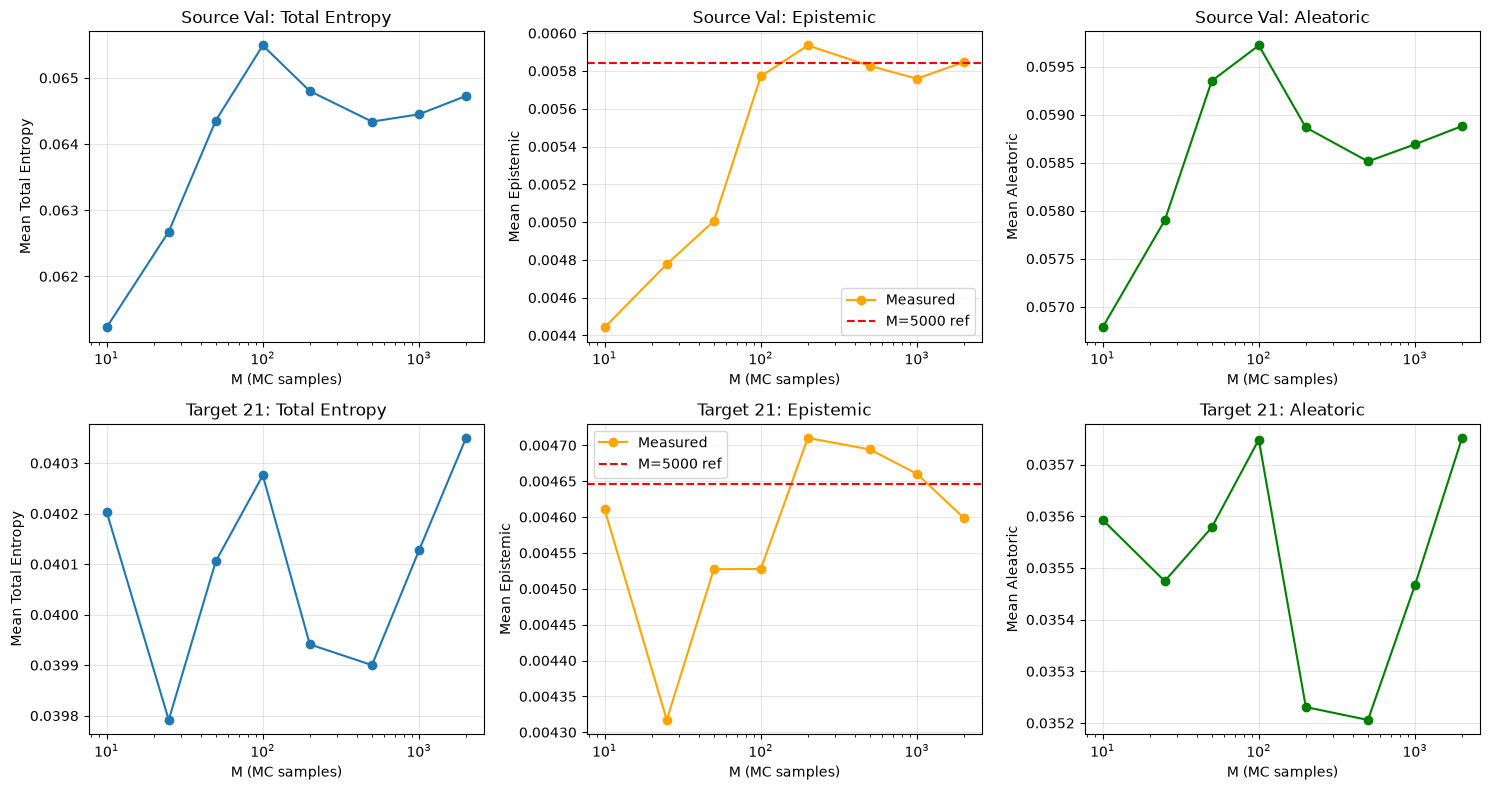


✓ Convergence plot generated
  Red dashed lines show M=5000 reference
  Oscillations around reference indicate MC noise dominates over convergence trend


In [13]:
# Plot convergence
fig, axes = plt.subplots(2, 3, figsize=(15, 8))

M_arr = np.array(convergence_results['M'])

# Source val
axes[0, 0].plot(M_arr, convergence_results['val_total_mean'], 'o-')
axes[0, 0].set_xlabel('M (MC samples)')
axes[0, 0].set_ylabel('Mean Total Entropy')
axes[0, 0].set_title('Source Val: Total Entropy')
axes[0, 0].set_xscale('log')
axes[0, 0].grid(True, alpha=0.3)

axes[0, 1].plot(M_arr, convergence_results['val_epi_mean'], 'o-', color='orange', label='Measured')
axes[0, 1].axhline(ref_val_epi, color='red', linestyle='--', linewidth=1.5, 
                   label=f'M={M_REFERENCE} ref')
axes[0, 1].set_xlabel('M (MC samples)')
axes[0, 1].set_ylabel('Mean Epistemic')
axes[0, 1].set_title('Source Val: Epistemic')
axes[0, 1].set_xscale('log')
axes[0, 1].grid(True, alpha=0.3)
axes[0, 1].legend()

axes[0, 2].plot(M_arr, convergence_results['val_ale_mean'], 'o-', color='green')
axes[0, 2].set_xlabel('M (MC samples)')
axes[0, 2].set_ylabel('Mean Aleatoric')
axes[0, 2].set_title('Source Val: Aleatoric')
axes[0, 2].set_xscale('log')
axes[0, 2].grid(True, alpha=0.3)

# Target
axes[1, 0].plot(M_arr, convergence_results['target_total_mean'], 'o-')
axes[1, 0].set_xlabel('M (MC samples)')
axes[1, 0].set_ylabel('Mean Total Entropy')
axes[1, 0].set_title(f'Target {representative_target_id}: Total Entropy')
axes[1, 0].set_xscale('log')
axes[1, 0].grid(True, alpha=0.3)

axes[1, 1].plot(M_arr, convergence_results['target_epi_mean'], 'o-', color='orange', label='Measured')
axes[1, 1].axhline(ref_target_epi, color='red', linestyle='--', linewidth=1.5,
                   label=f'M={M_REFERENCE} ref')
axes[1, 1].set_xlabel('M (MC samples)')
axes[1, 1].set_ylabel('Mean Epistemic')
axes[1, 1].set_title(f'Target {representative_target_id}: Epistemic')
axes[1, 1].set_xscale('log')
axes[1, 1].grid(True, alpha=0.3)
axes[1, 1].legend()

axes[1, 2].plot(M_arr, convergence_results['target_ale_mean'], 'o-', color='green')
axes[1, 2].set_xlabel('M (MC samples)')
axes[1, 2].set_ylabel('Mean Aleatoric')
axes[1, 2].set_title(f'Target {representative_target_id}: Aleatoric')
axes[1, 2].set_xscale('log')
axes[1, 2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\n✓ Convergence plot generated")
print(f"  Red dashed lines show M={M_REFERENCE} reference")
print(f"  Oscillations around reference indicate MC noise dominates over convergence trend")

In [14]:
# Apply convergence criterion with combined relative + absolute thresholds
# and 3-value stability window

RELATIVE_THRESHOLD = 0.01  # 1% relative change

print("\n" + "=" * 60)
print("CONVERGENCE CRITERION")
print("=" * 60)
print(f"\nDefinition:")
print(f"  1. Reference: M_REFERENCE={M_REFERENCE} (independent, not in M_VALUES)")
print(f"  2. Point criterion (must satisfy BOTH):")
print(f"     - Relative deviation < {RELATIVE_THRESHOLD*100:.0f}% from reference")
print(f"     - Absolute deviation < {ABSOLUTE_THRESHOLD:.6f} from reference")
print(f"  3. Stability window: M and next 2 values must ALL pass point criterion")
print(f"  4. Selection: Smallest M meeting windowed criterion")
print(f"\nReference values (M={M_REFERENCE}):")
print(f"  Source val epistemic:  {ref_val_epi:.6f}")
print(f"  Target {representative_target_id} epistemic: {ref_target_epi:.6f}")

# Helper function: check if single M satisfies point criterion
def check_point_criterion(val_epi, target_epi, ref_val, ref_target):
    """Check if both val and target satisfy relative AND absolute thresholds."""
    val_rel_dev = abs(val_epi - ref_val) / ref_val
    val_abs_dev = abs(val_epi - ref_val)
    target_rel_dev = abs(target_epi - ref_target) / ref_target
    target_abs_dev = abs(target_epi - ref_target)
    
    val_ok = (val_rel_dev < RELATIVE_THRESHOLD) and (val_abs_dev < ABSOLUTE_THRESHOLD)
    target_ok = (target_rel_dev < RELATIVE_THRESHOLD) and (target_abs_dev < ABSOLUTE_THRESHOLD)
    
    return val_ok and target_ok, val_rel_dev, val_abs_dev, target_rel_dev, target_abs_dev

# Compute point criterion for all M values
print(f"\nPoint-wise convergence analysis:")
print(f"{'M':>6s} | {'Val %Δ':>8s} | {'Val |Δ|':>10s} | {'Tgt %Δ':>8s} | {'Tgt |Δ|':>10s} | {'Point OK':>9s}")
print("-" * 80)

point_results = []
for i, M in enumerate(convergence_results['M']):
    val_epi = convergence_results['val_epi_mean'][i]
    target_epi = convergence_results['target_epi_mean'][i]
    
    point_ok, val_rel, val_abs, tgt_rel, tgt_abs = check_point_criterion(
        val_epi, target_epi, ref_val_epi, ref_target_epi
    )
    point_results.append(point_ok)
    
    print(f"{M:6d} | {val_rel*100:7.2f}% | {val_abs:10.6f} | {tgt_rel*100:7.2f}% | "
          f"{tgt_abs:10.6f} | {'YES' if point_ok else 'no':>9s}")

# Apply 3-value stability window
print("\n" + "=" * 60)
print("STABILITY WINDOW (3 consecutive values)")
print("=" * 60)
print(f"{'M':>6s} | {'Window':>15s} | {'All pass?':>9s} | {'Converged':>10s}")
print("-" * 60)

M_FIXED = None
WINDOW_SIZE = 3

for i, M in enumerate(convergence_results['M']):
    # Check if we have enough following values for full window
    if i + WINDOW_SIZE > len(convergence_results['M']):
        # Not enough values to complete window
        # We require full 3-value window, so mark as non-converged for tail values
        window_str = f"[{M}, ...] incomplete"
        all_pass = False
        print(f"{M:6d} | {window_str:>15s} | {'no':>9s} | {'no (tail)':>10s}")
    else:
        # Check window: current M + next 2
        window_M = convergence_results['M'][i:i+WINDOW_SIZE]
        window_pass = point_results[i:i+WINDOW_SIZE]
        all_pass = all(window_pass)
        
        window_str = f"{window_M}"
        
        converged_str = 'YES' if (all_pass and M_FIXED is None) else 'no'
        if all_pass and M_FIXED is None:
            M_FIXED = M
        
        print(f"{M:6d} | {str(window_M):>15s} | {'YES' if all_pass else 'no':>9s} | {converged_str:>10s}")

print("=" * 60)

# Final selection
if M_FIXED is not None:
    print(f"\n✓ SELECTED: M_FIXED = {M_FIXED}")
    print(f"\nRationale: Smallest M where M and next 2 values in M_VALUES all satisfy:")
    print(f"  - Relative deviation < {RELATIVE_THRESHOLD*100:.0f}% from M={M_REFERENCE}")
    print(f"  - Absolute deviation < {ABSOLUTE_THRESHOLD:.6f} from M={M_REFERENCE}")
    print(f"  (on both source val and target {representative_target_id})")
else:
    # No M satisfied windowed criterion - MC noise dominates
    M_FIXED = M_REFERENCE
    print(f"\n⚠ NO M in M_VALUES satisfied windowed convergence criterion")
    print(f"\nInterpretation: Monte Carlo noise dominates over convergence trend")
    print(f"                at all tested M values when compared to M={M_REFERENCE}.")
    print(f"                Epistemic signal is small on this dataset (~{ref_val_epi:.1e})")
    print(f"                and stabilizing it requires many samples.")
    print(f"\n✓ SELECTED: M_FIXED = {M_FIXED} (= M_REFERENCE)")
    print(f"\nRationale: Use highest available M as most reliable estimate")


CONVERGENCE CRITERION

Definition:
  1. Reference: M_REFERENCE=5000 (independent, not in M_VALUES)
  2. Point criterion (must satisfy BOTH):
     - Relative deviation < 1% from reference
     - Absolute deviation < 0.000500 from reference
  3. Stability window: M and next 2 values must ALL pass point criterion
  4. Selection: Smallest M meeting windowed criterion

Reference values (M=5000):
  Source val epistemic:  0.005840
  Target 21 epistemic: 0.004646

Point-wise convergence analysis:
     M |   Val %Δ |    Val |Δ| |   Tgt %Δ |    Tgt |Δ| |  Point OK
--------------------------------------------------------------------------------
    10 |   23.93% |   0.001398 |    0.76% |   0.000035 |        no
    25 |   18.20% |   0.001063 |    7.08% |   0.000329 |        no
    50 |   14.31% |   0.000836 |    2.56% |   0.000119 |        no
   100 |    1.18% |   0.000069 |    2.55% |   0.000119 |        no
   200 |    1.62% |   0.000095 |    1.38% |   0.000064 |        no
   500 |    0.23% |   

## 5. Generate BALD Artifact for All Subjects

Compute predictive distributions with M_FIXED for:
- Source validation set
- All 10 target subjects

Save to disk for use in §6/§7.

In [15]:
# Show M_FIXED at top of section
print("=" * 60)
print(f"FIXED MC SAMPLES: M_FIXED = {M_FIXED}")
print(f"(Selected via convergence check above)")
print("=" * 60)

# Will use this seed for all final predictive computations
FINAL_SEED = 456
print(f"\nGenerator seed for final predictions: {FINAL_SEED}")
print(f"\nComputing BALD artifact (this will take ~1 minute)...\n")

artifact = {}

# Source validation
print("Source validation set...")
pred_val = laplace.predictive(
    model, X_val_torch, M=M_FIXED, temperature=1.0,
    generator=torch.Generator().manual_seed(FINAL_SEED)
)
artifact['source_val'] = {
    'subject_ids': val_subjects,
    'X': X_val_torch.numpy(),
    'y': y_val.numpy(),
    'mean_probs': pred_val['mean_probs'].numpy(),
    'total_entropy': pred_val['total_entropy'].numpy(),
    'aleatoric': pred_val['aleatoric'].numpy(),
    'epistemic': pred_val['epistemic'].numpy(),
}
print(f"  {len(y_val)} samples, mean_epi={pred_val['epistemic'].mean():.4f}")

# All target subjects
artifact['targets'] = {}
for sid in sorted(split.target_subjects):
    ds_t = dataset.filter_subjects([sid])
    X_t = torch.tensor(split.scaler.transform(ds_t.X), dtype=torch.float32)
    y_t = np.array([label_map[y] for y in ds_t.y])
    
    pred_t = laplace.predictive(
        model, X_t, M=M_FIXED, temperature=1.0,
        generator=torch.Generator().manual_seed(FINAL_SEED)
    )
    
    artifact['targets'][int(sid)] = {
        'X': X_t.numpy(),
        'y': y_t,
        'mean_probs': pred_t['mean_probs'].numpy(),
        'total_entropy': pred_t['total_entropy'].numpy(),
        'aleatoric': pred_t['aleatoric'].numpy(),
        'epistemic': pred_t['epistemic'].numpy(),
    }
    
    print(f"Target {sid:2d}: {len(y_t)} samples, "
          f"mean_epi={pred_t['epistemic'].mean():.4f}")

print("\n✓ BALD artifact computed for all subjects")

FIXED MC SAMPLES: M_FIXED = 5000
(Selected via convergence check above)

Generator seed for final predictions: 456

Computing BALD artifact (this will take ~1 minute)...

Source validation set...
  687 samples, mean_epi=0.0058
Target  7: 155 samples, mean_epi=0.0167
Target  8: 127 samples, mean_epi=0.0388
Target 11: 159 samples, mean_epi=0.0059
Target 15: 144 samples, mean_epi=0.0027
Target 19: 131 samples, mean_epi=0.0447
Target 20: 147 samples, mean_epi=0.0515
Target 21: 144 samples, mean_epi=0.0046
Target 22: 124 samples, mean_epi=0.0228
Target 27: 152 samples, mean_epi=0.0002
Target 30: 192 samples, mean_epi=0.0025

✓ BALD artifact computed for all subjects


## 6. Save Artifact to Disk

In [16]:
# Save as .npz
output_dir = Path("../data")
output_dir.mkdir(exist_ok=True)
output_path = output_dir / "har_bald_artifact.npz"

# Flatten structure for npz
save_dict = {
    'M_FIXED': M_FIXED,
    'relative_threshold': RELATIVE_THRESHOLD,  # corrected: was CONVERGENCE_THRESHOLD
    'absolute_threshold': ABSOLUTE_THRESHOLD,  # new: absolute threshold used
    'M_REFERENCE': M_REFERENCE,  # new: reference M value
    'final_seed': FINAL_SEED,
    'tau_prior': history['tau_prior'],
    # Source val
    'source_val_subjects': artifact['source_val']['subject_ids'],
    'source_val_X': artifact['source_val']['X'],
    'source_val_y': artifact['source_val']['y'],
    'source_val_mean_probs': artifact['source_val']['mean_probs'],
    'source_val_total_entropy': artifact['source_val']['total_entropy'],
    'source_val_aleatoric': artifact['source_val']['aleatoric'],
    'source_val_epistemic': artifact['source_val']['epistemic'],
}

# Targets (one entry per subject)
for sid, data in artifact['targets'].items():
    save_dict[f'target_{sid}_X'] = data['X']
    save_dict[f'target_{sid}_y'] = data['y']
    save_dict[f'target_{sid}_mean_probs'] = data['mean_probs']
    save_dict[f'target_{sid}_total_entropy'] = data['total_entropy']
    save_dict[f'target_{sid}_aleatoric'] = data['aleatoric']
    save_dict[f'target_{sid}_epistemic'] = data['epistemic']

save_dict['target_subject_ids'] = sorted(split.target_subjects)

np.savez_compressed(output_path, **save_dict)

print(f"✓ Saved to: {output_path}")
print(f"  File size: {output_path.stat().st_size / 1024:.1f} KB")
print(f"\nMetadata saved:")
print(f"  M_FIXED = {M_FIXED}")
print(f"  M_REFERENCE = {M_REFERENCE}")
print(f"  relative_threshold = {RELATIVE_THRESHOLD}")
print(f"  absolute_threshold = {ABSOLUTE_THRESHOLD}")

✓ Saved to: ../data/har_bald_artifact.npz
  File size: 4224.1 KB

Metadata saved:
  M_FIXED = 5000
  M_REFERENCE = 5000
  relative_threshold = 0.01
  absolute_threshold = 0.0005


## 7. Verification: Summary Table

In [17]:
# Simple summary to verify artifact was generated correctly
# NO analysis or interpretation (that's §6/§7)
print("\n" + "=" * 60)
print("BALD ARTIFACT SUMMARY (verification only, no analysis)")
print("=" * 60)

print(f"\nSource validation ({len(artifact['source_val']['y'])} samples):")
print(f"  Mean epistemic:  {artifact['source_val']['epistemic'].mean():.4f}")
print(f"  Mean aleatoric:  {artifact['source_val']['aleatoric'].mean():.4f}")
print(f"  Mean total:      {artifact['source_val']['total_entropy'].mean():.4f}")

print(f"\nTarget subjects ({len(artifact['targets'])} subjects):")
print(f"{'Subject':>7s} | {'N':>4s} | {'Epistemic':>10s} | {'Aleatoric':>10s} | {'Total':>10s}")
print("-" * 60)
for sid in sorted(artifact['targets'].keys()):
    data = artifact['targets'][sid]
    print(f"{sid:7d} | {len(data['y']):4d} | "
          f"{data['epistemic'].mean():10.4f} | "
          f"{data['aleatoric'].mean():10.4f} | "
          f"{data['total_entropy'].mean():10.4f}")

print("\n" + "=" * 60)
print("§5 COMPLETE - ARTIFACT READY FOR §6/§7")
print("=" * 60)
print(f"\nKey outputs:")
print(f"  M_FIXED = {M_FIXED}")
if M_FIXED == M_REFERENCE:
    print(f"  (No M in M_VALUES met windowed criterion → used M_REFERENCE)")
print(f"  Artifact location: {output_path}")
print(f"  Contains: source val + {len(artifact['targets'])} target subjects")
print(f"  Fields: mean_probs, total_entropy, aleatoric, epistemic")
print(f"\nConvergence criterion used:")
print(f"  Reference: M_REFERENCE={M_REFERENCE} (independent)")
print(f"  Relative threshold: {RELATIVE_THRESHOLD*100:.0f}%")
print(f"  Absolute threshold: {ABSOLUTE_THRESHOLD:.6f}")
print(f"  Stability window: 3 consecutive values")
print(f"\nNext steps (§6/§7):")
print(f"  - Semantic checks (epistemic vs aleatoric dominance)")
print(f"  - Calibration analysis (ECE, NLL, reliability diagrams)")
print(f"  - Correlation with shift proxy")
print(f"\nDO NOT perform these analyses here - that's §6/§7.")


BALD ARTIFACT SUMMARY (verification only, no analysis)

Source validation (687 samples):
  Mean epistemic:  0.0058
  Mean aleatoric:  0.0591
  Mean total:      0.0649

Target subjects (10 subjects):
Subject |    N |  Epistemic |  Aleatoric |      Total
------------------------------------------------------------
      7 |  155 |     0.0167 |     0.0760 |     0.0927
      8 |  127 |     0.0388 |     0.1413 |     0.1801
     11 |  159 |     0.0059 |     0.0394 |     0.0454
     15 |  144 |     0.0027 |     0.0242 |     0.0269
     19 |  131 |     0.0447 |     0.1189 |     0.1636
     20 |  147 |     0.0515 |     0.1782 |     0.2298
     21 |  144 |     0.0046 |     0.0358 |     0.0405
     22 |  124 |     0.0228 |     0.0645 |     0.0872
     27 |  152 |     0.0002 |     0.0018 |     0.0020
     30 |  192 |     0.0025 |     0.0293 |     0.0318

§5 COMPLETE - ARTIFACT READY FOR §6/§7

Key outputs:
  M_FIXED = 5000
  (No M in M_VALUES met windowed criterion → used M_REFERENCE)
  Artifact 